# Gurobi Monotonic Approximation of Prices
version 1.1

In [68]:
# Let's start off by loading in the packages

# Let's load in the necessary packages
import pandas as pd
import datetime
import os
import timeit
import matplotlib.pyplot as plt
import gurobipy as gp
from gurobipy import GRB
import numpy as np
from scipy.optimize import curve_fit

### Loading in some data

In [69]:
# Loading in the data first.
# Let's load in the data here, and for now, let's make it just for four hours.

file_name = os.fsdecode("marco_data.csv")
workbook = pd.read_csv(file_name)
workbook = workbook.filter(items=["date", "he", "size","flexible","price","ail","mkt_price"]) # Gets the columns that we need


workbook = workbook.query('date=="2024-04-10"') # Remove this to take out the filter for the day.

# Getting the columns we need.
#merit_data = workbook.filter(items=["date", "he", "size","flexible","price","mkt_price","ail","datetime"]) # Gets the columns that we need
merit_data = workbook
# I added "datetime" above so that it will be easier to filter out the merit data when looping through.

In [70]:
bids = merit_data.query('he==15')
bids=bids.sort_values('price').reset_index(drop = True)
# bids=bids.assign(merit=bids['size'].cumsum())
bids['merit'] = bids['size'].cumsum() # Old code is above

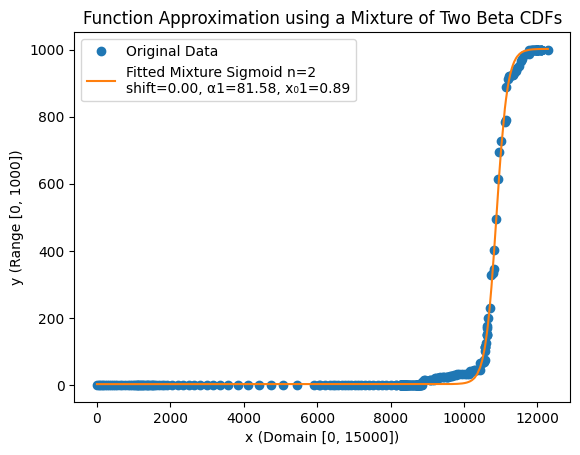

In [71]:
from scipy.stats import beta

# Example data (you would use your actual data here)
#data = np.random.beta(2, 5, size=1000)  # Example data from a Beta distribution

# Fit the Beta distribution to the data
#alpha, beta_param, loc, scale = beta.fit(data, floc=0, fscale=1)  # Force it to be in [0, 1]

bids_temp=bids
x = bids_temp['merit']
x = x.to_numpy()
y = bids_temp['price']

# Normalize the domain (x) to [0, 1]
x_normalized = (x - np.min(x)) / (np.max(x) - np.min(x))

# Normalize the range (y) to [0, 1]
y_normalized = y/1000

# Define the weighted mixture of two Beta CDFs
def mixture_beta_cdf(x, alpha1, beta1, alpha2, beta2, w):
    beta_cdf1 = beta.cdf(x, alpha1, beta1)
    beta_cdf2 = beta.cdf(x, alpha2, beta2)
    return w * beta_cdf1 + (1 - w) * beta_cdf2

def mixture_sigmoid(x, *params):
    # Extract parameters for the two sigmoids and their mixture
    k1 = params[0]  # Steepness of the first sigmoid
    x01 = params[1]  # Center of the first sigmoid
    k2 = params[2]  # Steepness of the second sigmoid
    x02 = params[3]  # Center of the second sigmoid
    w = params[4]    # Weight of the first sigmoid
    shift = params[5]  # Overall vertical shift

    # Define the two sigmoid functions
    sigmoid1 = 1 / (1 + np.exp(-k1 * (x - x01)))
    sigmoid2 = 1 / (1 + np.exp(-k2 * (x - x02)))
    
    # Weighted mixture of the two sigmoids
    return w * sigmoid1 + (1 - w) * sigmoid2 + shift

def sigmoid(x, *params):
    # Extract parameters for the two sigmoids and their mixture
    k1 = params[0]  # Steepness of the first sigmoid
    x01 = params[1]  # Center of the first sigmoid
    shift = params[2]  # Overall vertical shift

    # Define the two sigmoid functions
    return 1 / (1 + np.exp(-k1 * (x - x01))) + shift


# Fit the mixture Beta CDF to the normalized data
#popt, _ = curve_fit(mixture_sigmoid, x_normalized, y_normalized, p0= [0, 0.5, .75, .5,.5,0.25,.5]) # [k1, x01, k2, x02, w, shift])

popt, _ = curve_fit(sigmoid, x_normalized, y_normalized, p0= [0.5, .75, 0]) # [k1, x01, k2, x02, w, shift])


# Retrieve fitted parameters
params = popt

# Approximate y using the fitted mixture Beta CDF
#y_approx_normalized = mixture_beta_cdf(x_normalized, alpha1_fitted, beta1_fitted, alpha2_fitted, beta2_fitted, w_fitted)
#y_approx_normalized = mixture_sigmoid(x_normalized,*params)
y_approx_normalized = sigmoid(x_normalized,*params)

# Rescale the approximated y back to original range [0, 1000]
y_approx = y_approx_normalized * 1000

# Plot the original data and the approximation
plt.plot(x, y, 'o', label='Original Data')
#plt.plot(x, y_approx, '-', label=f'Fitted Mixture Beta CDF\n(α1={alpha1_fitted:.2f}, β1={beta1_fitted:.2f}, α2={alpha2_fitted:.2f}, β2={beta2_fitted:.2f}, w={w_fitted:.2f})')
plt.plot(x, y_approx, '-', label=f"Fitted Mixture Sigmoid n=2\n"
                                 f"shift={params[2]:.2f}, α1={params[0]:.2f}, "
                                 f"x₀1={params[1]:.2f}")
plt.title("Function Approximation using a Mixture of Two Beta CDFs")
plt.xlabel('x (Domain [0, 15000])')
plt.ylabel('y (Range [0, 1000])')
plt.legend()
plt.show()

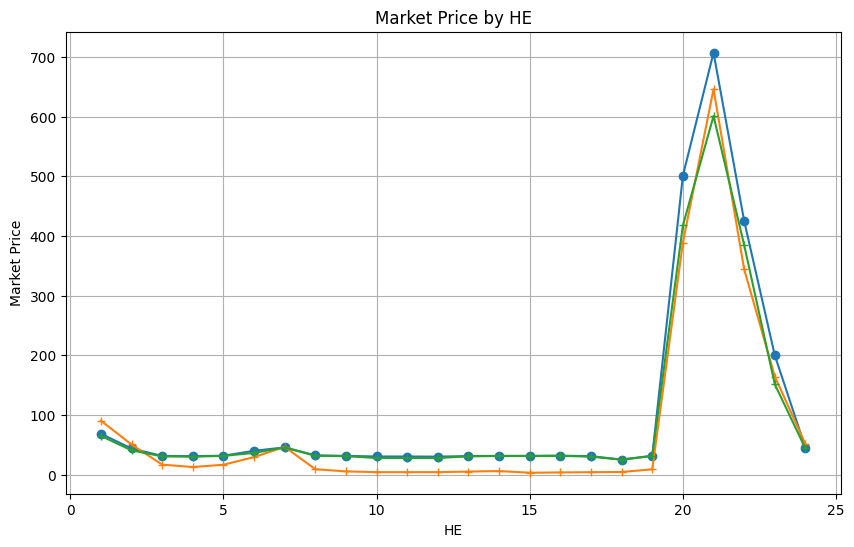

In [72]:
def approx_merit(bids, start_vals):
    """
    Fit a mixture of two Beta CDFs to normalized data from the 'merit' and 'price' columns of bids.
    
    Parameters:
    bids (DataFrame): Data containing 'merit' and 'price' columns.
    start_vals (list): Starting values for the parameters.

    Returns:
    tuple: Vector of parameters for defining the mixed beta CDF and the maximum merit value.
    """
    # Extract data from bids
    x = bids['merit'].to_numpy()
    y = bids['price'].to_numpy()
    
    # Normalize x (domain) and y (range) to [0, 1]
    x_max = np.max(x)
    x_normalized = x / x_max
    y_normalized = y / 1000  # Prices are always bounded between 0 and 1000
  
    # Print the start values for debugging
    #print("Starting values:", start_vals)
    
    # Fit the mixture Beta CDF to the normalized data
    #popt, _ = curve_fit(mixture_beta_cdf, x_normalized, y_normalized, p0=start_vals)
    popt, _ = curve_fit(sigmoid, x_normalized, y_normalized, p0=start_vals)
    
    return popt, x_max

# Example starting values
initial_params = [2, 5, 5, 2, 0.5, 0]  # Initial guess for parameters
initial_params= [0, 0.5, .75] #sigmoid parameters
#start_vals, max_merit = approx_merit(bids_temp, initial_params)

#print("Fitted parameters:", start_vals)

#ail_target=bids_temp['ail'].iat[0]
#ail_norm=ail_target/max_merit

#print(mixture_beta_cdf(ail_norm, alpha1_fitted, beta1_fitted, alpha2_fitted, beta2_fitted, w_fitted)*1000)


#print(bids_temp['mkt_price'].iat[0])
#print(parameters)


for (date, he), group in merit_data.groupby(['date', 'he']):
  bids = group
  bids=bids.sort_values('price').reset_index(drop = True)
  #bids=bids.assign(merit=bids['size'].cumsum())
  bids['merit'] = bids['size'].cumsum() # Old code is above 
  parameters, max_merit = approx_merit(bids,initial_params)
  ail_target=bids['ail'].iat[0]
  ail_norm=ail_target/max_merit
  #merit_data.loc[group.index, 'approx_price'] = mixture_beta_cdf(ail_norm, *parameters)*1000
  merit_data.loc[group.index, 'approx_price'] = sigmoid(ail_norm, *parameters)*1000
  merit_data.loc[group.index, 'max_merit'] = max_merit
  params_df = pd.Series([parameters.tolist()] * len(group), index=group.index)
  merit_data.loc[group.index, 'approx_params'] = params_df
  # Choose breakpoints (you can choose them based on your data or other criteria)
  breakpoints = np.arange(0, max_merit*1.1, 10)  # Including 0 and excluding 1000
  interp_values = np.interp(breakpoints, bids['merit'], bids['price'])
  merit_data.loc[group.index, 'interp_price'] = np.interp(ail_target, bids['merit'], bids['price'])
  # Store the results in the dictionary with a tuple as the key
  #interp_results[(date, he)] = interp_values
  # Example usage: Print interpolated values for each group
  # Get corresponding y values using interpolation
  #interp_value = 
  # Display breakpoints and corresponding values
  #print("Breakpoints:", breakpoints)
  #print("Values:", interp_values)

# Optional: Plot the original function and the piecewise linear approximation
interp_mkt_price_by_he = merit_data.groupby('he')['interp_price'].mean()
avg_mkt_price_by_he = merit_data.groupby('he')['mkt_price'].mean()
approx_mkt_price_by_he = merit_data.groupby('he')['approx_price'].mean()
# Plot the original data and the approximation
plt.figure(figsize=(10, 6))
avg_mkt_price_by_he.plot(kind='line', marker='o')
approx_mkt_price_by_he.plot(kind='line', marker='+')
interp_mkt_price_by_he.plot(kind='line', marker='+')
#plt.plot(breakpoints, interp_values, 'ro-', label='Piecewise Linear Approximation')
#plt.plot(breakpoints, interp_values, 'ro-', label='Piecewise Linear Approximation')
plt.title(f"Market Price by HE")
plt.xlabel("HE")
plt.ylabel("Market Price")
plt.grid(True)
plt.show()


In [73]:
# Adding in battery data:

#### BATTERY DATA ####

# Creating the parameters of the battery here, and if we want to make changes to our battery this is where we can adjust it.
batt_dict = {
    'max_charge_rate':100,
    'max_discharge_rate':100,
    'capacity':400,
    'charge_eff':0.05,
    'discharge_eff':0.05,
    'min_soc':0.05,
    'max_soc':0.95,
    'initial_soc':200
}

battDF = pd.DataFrame.from_dict(batt_dict, orient = 'index').transpose()
del batt_dict
battDF

,max_charge_rate,max_discharge_rate,capacity,charge_eff,discharge_eff,min_soc,max_soc,initial_soc
0,100.0,100.0,400.0,0.05,0.05,0.05,0.95,200.0


In [74]:
# Now we start with creating the gurobi model.

model_data_list = []

# Group by date and he
for (date, he), group in merit_data.groupby(['date', 'he']):
    # Sort bids by price
    bids = group.sort_values('price').reset_index(drop=True)
    # Calculate cumulative merit
    bids['merit'] = bids['size'].cumsum()
    ail = bids['ail'].max()
    price=bids['mkt_price'].max()
    max_bid=bids['merit'].max()
     # Append the relevant information to the list
    model_data_list.append({
        'date': date,
        'he': he,
        'ail': ail,
        'bids': bids['merit'].values.tolist(),  # Store merit as a list
        'prices': bids['price'].values.tolist(),   # Store prices as a list
        'mkt_price':price,
        'max_bid':max_bid,

    })

# Convert the list of dictionaries into a DataFrame
model_data = pd.DataFrame(model_data_list)

#print(model_data)

bm = gp.Model("qp")

inf = GRB.INFINITY

In [75]:
## Let's create the variables
# It's slightly different now because we're using Gurobi
tIndex=len(model_data)
# Create an index for the number of periods that's an integer; easier to use.
# Now creating the variables of a simpler battery
vBattPower = [bm.addVar(lb = -inf, ub = inf, name = "") for _ in range(tIndex)]
# Battery State of Charge Variable, which acts as a constraint as well.
vSOC = [bm.addVar(lb = battDF.iloc[0]['capacity']*battDF.iloc[0]['min_soc'], ub = battDF.iloc[0]['capacity']*battDF.iloc[0]['max_soc'], name = "") for _ in range(tIndex)]

# Simple Price function that governs prices:
vPrice = [bm.addVar(lb = -inf, ub = inf, name = "") for _ in range(tIndex)]

In [76]:
## CONSTRAINTS

for i in range(len(model_data)):

    #---------------------------------------------------------------------------------------------------------------------------
    #### Battery Constraints:

    # Power flow constraints
    bm.addConstr(vBattPower[i] >= -battDF.iloc[0]['max_discharge_rate'])
    bm.addConstr(vBattPower[i] <= battDF.iloc[0]['max_charge_rate'])

    # Law of Motion for the state of charge of the battery:
    # NOTE: Because we are doing it this way, if BattPower is positive then our battery is charging.
    if i == 0:
        bm.addConstr(vSOC[i] == battDF.iloc[0]['initial_soc'] + vBattPower[i])
    else:
        bm.addConstr(vSOC[i] == vSOC[i-1] + vBattPower[i])


    merit_order= np.array(model_data.loc[i, 'bids'])
    prices=np.array(model_data.loc[i, 'prices'])
    load= model_data.loc[i, 'ail']
    delta_1 = battDF.iloc[0]['max_discharge_rate']*1.25
    delta_2 = battDF.iloc[0]['max_charge_rate']*1.25
    # Filter merit_order for values within +/- battery possible range from load
    filtered_price = prices[(merit_order >= load - delta_1) & (merit_order <= load + delta_2)]
    #filtered_merit_order = merit_order[(merit_order >= load-delta_1) & (merit_order <= load+delta_2)]-load
    max_price=max(filtered_price)
    min_price=min(filtered_price)
    #max_price=min_price=0
    #print(filtered_merit_order,filtered_price)
    #for i in range(len(filtered_merit_order) - 1):
    #    bm.addGenConstrPWL(
    #     vBattPower[i],  # The Gurobi variable for merit order
    #     vPrice[i],       # The Gurobi variable for price
    #     filtered_merit_order,  # The x-values for breakpoints (merit order)
    #     filtered_price   # The y-values for corresponding prices (breakpoint values)
    #    )
    # #### Price Constraint:
    #bm.addConstr(vPrice[i] == model_data.loc[i, 'mkt_price'])
    bm.addConstr(vPrice[i] == model_data.loc[i, 'mkt_price']+vBattPower[i]*(max_price-min_price)/(delta_1+delta_2))

    #print((max_price-min_price)/(delta_1+delta_2))


    # Now create the piecewise linear constraint
    

# Set the objective to maximize profit
bm.setObjective(gp.quicksum(vPrice[i] * (vBattPower[i]) for i in range(len(model_data))), GRB.MINIMIZE)

# Optimize the model
bm.optimize()



Gurobi Optimizer version 11.0.3 build v11.0.3rc0 (win64 - Windows 11.0 (22631.2))

CPU model: 12th Gen Intel(R) Core(TM) i7-12800H, instruction set [SSE2|AVX|AVX2]
Thread count: 14 physical cores, 20 logical processors, using up to 20 threads

Academic license 2565375 - for non-commercial use only - registered to al___@ualberta.ca
Optimize a model with 96 rows, 72 columns and 167 nonzeros
Model fingerprint: 0xd3050468
Model has 24 quadratic objective terms
Coefficient statistics:
  Matrix range     [2e-03, 1e+00]
  Objective range  [0e+00, 0e+00]
  QObjective range [2e+00, 2e+00]
  Bounds range     [2e+01, 4e+02]
  RHS range        [3e+01, 7e+02]
Presolve removed 49 rows and 1 columns

Continuous model is non-convex -- solving as a MIP

Presolve removed 49 rows and 1 columns
Presolve time: 0.00s
Presolved: 96 rows, 96 columns, 286 nonzeros
Presolved model has 24 bilinear constraint(s)
Variable types: 96 continuous, 0 integer (0 binary)
Found heuristic solution: objective -137551.1111



In [77]:
# Let's collect the battery power values and the price values:
prices = []
batt_power = []
state_of_charge = []

for i in range(tIndex):
    prices.append(vPrice[i].X)
    batt_power.append(vBattPower[i].X)
    state_of_charge.append(vSOC[i].X)





In [78]:
# Let's put our results in a table:

battery_results = pd.DataFrame()

battery_results['hour_ending'] = model_data['he']
battery_results['simple_prices'] = prices
battery_results['batt_power'] = batt_power
battery_results['state_of_charge'] = state_of_charge

#battery_results

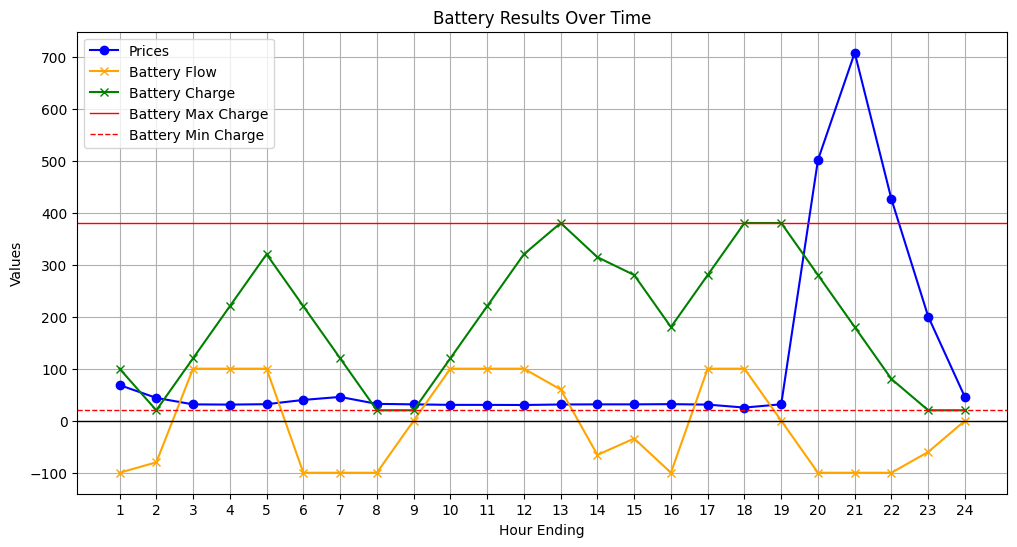

In [25]:
# Plotting the results

plt.figure(figsize=(12, 6))

# Customize each series
plt.plot(battery_results['hour_ending'], battery_results['simple_prices'], label='Prices', color='blue', marker='o', linestyle='-')
plt.plot(battery_results['hour_ending'], battery_results['batt_power'], label='Battery Flow', color='orange', marker='x', linestyle='-')
plt.plot(battery_results['hour_ending'], battery_results['state_of_charge'], label='Battery Charge', color='green', marker='x', linestyle='-')
#plt.plot(battery_results['hour_ending'], battery_results['state_of_charge'], label='State of Charge', color='green', marker='s', linestyle=':')
plt.axhline(0, color='black', linestyle='-', linewidth=1)  # Red dashed line at y=0
plt.axhline(400*.95, color='red', linestyle='-', linewidth=1,label='Battery Max Charge')  # Red dashed line at y=0
plt.axhline(400*.05, color='red', linestyle='--', linewidth=1,label='Battery Min Charge')  # Red dashed line at y=0
# Titles and labels
plt.title('Battery Results Over Time')
plt.xlabel('Hour Ending')
plt.ylabel('Values')
plt.xticks(battery_results['hour_ending'])
plt.grid()
plt.legend()
plt.show()